In [94]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Download latest version
path = kagglehub.dataset_download("jakeshbohaju/brain-tumor")
csv_file_path = os.path.join(path, "Brain Tumor.csv")

/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv
/kaggle/input/datasets/jakeshbohaju/brain-tumor/Brain Tumor.csv
/kaggle/input/datasets/jakeshbohaju/brain-tumor/bt_dataset_t3.csv
/kaggle/input/datasets/jakeshbohaju/brain-tumor/Brain Tumor/Brain Tumor/Image3202.jpg
/kaggle/input/datasets/jakeshbohaju/brain-tumor/Brain Tumor/Brain Tumor/Image1153.jpg
/kaggle/input/datasets/jakeshbohaju/brain-tumor/Brain Tumor/Brain Tumor/Image1465.jpg
/kaggle/input/datasets/jakeshbohaju/brain-tumor/Brain Tumor/Brain Tumor/Image688.jpg
/kaggle/input/datasets/jakeshbohaju/brain-tumor/Brain Tumor/Brain Tumor/Image233.jpg
/kaggle/input/datasets/jakeshbohaju/brain-tumor/Brain Tumor/Brain Tumor/Image3561.jpg
/kaggle/input/datasets/jakeshbohaju/brain-tumor/Brain Tumor/Brain Tumor/Image1166.jpg
/kaggle/input/datasets/jakeshbohaju/brain-tumor/Brain Tumor/Brain Tumor/Image1975.jpg
/kaggle/input/datasets/jakeshbohaju/brain-tumor/Brain Tumor/Brain Tumor/Image1263.jpg
/kaggle/input/datasets/jakeshbo

In [75]:
df = pd.read_csv(csv_file_path)
print("First 5 records:", df.head())

First 5 records:     Image  Class      Mean     Variance  Standard Deviation   Entropy  \
0  Image1      0  6.535339   619.587845           24.891522  0.109059   
1  Image2      0  8.749969   805.957634           28.389393  0.266538   
2  Image3      1  7.341095  1143.808219           33.820234  0.001467   
3  Image4      1  5.958145   959.711985           30.979219  0.001477   
4  Image5      0  7.315231   729.540579           27.010009  0.146761   

   Skewness   Kurtosis    Contrast    Energy       ASM  Homogeneity  \
0  4.276477  18.900575   98.613971  0.293314  0.086033     0.530941   
1  3.718116  14.464618   63.858816  0.475051  0.225674     0.651352   
2  5.061750  26.479563   81.867206  0.031917  0.001019     0.268275   
3  5.677977  33.428845  151.229741  0.032024  0.001026     0.243851   
4  4.283221  19.079108  174.988756  0.343849  0.118232     0.501140   

   Dissimilarity  Correlation     Coarseness  
0       4.473346     0.981939  7.458341e-155  
1       3.220072     0.

In [76]:
features = ["Mean", "Variance", "Standard Deviation", "Entropy", "Skewness", "Kurtosis", "Contrast",
            "Energy", "ASM", "Homogeneity", "Dissimilarity", "Correlation"]

X = df[features].to_numpy()
y = df["Class"].to_numpy()
np.random.seed(42)

indices = np.random.permutation(len(X))

X = X[indices]
y = y[indices]

split = int(0.8 * len(X))

X_train = X[:split]
y_train = y[:split]

X_val = X[split:]
y_val = y[split:]

In [77]:
def normalization(x):
    mean = np.mean(x, axis=0)
    std = np.std(x, axis=0)
    x_scaled = (x - mean) / std
    return x_scaled

In [78]:
X_train = normalization(X_train)
X_val = normalization(X_val)

In [79]:
def sigmoid(z):
    g = 1/(1 + np.exp(-z))
    return g

In [80]:
def cost_function(w, b, y, x, l):
    m = x.shape[0]
    n = w.shape[0]
    sum = 0
    lambdaSum = 0
    for i in range(m):
        z = np.dot(w, x[i]) + b
        g = sigmoid(z)
        sum = sum + (y[i] * np.log(g)) + (1 - y[i])* np.log(1 - g)
    for j in range(n):
        lambdaSum = lambdaSum + w[j]**2
    
    cost = (-1/m) * sum + (l/(2*m)) * lambdaSum
    return cost

In [81]:
def derivatives(w, b, y, x, l):
    m = x.shape[0]
    dw = np.zeros(w.shape)
    db = 0
    sum = 0
    for i in range(m):
        z = np.dot(w, x[i]) + b
        g = sigmoid(z)
        dw = dw + (g - y[i]) * x[i]
        db += g - y[i]
    dw = (1/m) * dw + (l/m) * w
    db = (1/m) * db
    return dw, db
    

In [84]:
def gradient(w, b, y, x, iterations, alpha, l):
    for j in range(iterations):
        dw, db = derivatives(w, b, y, x, l)
        w = w - alpha * dw
        b = b - alpha * db
        if (j + 1) % 100 == 0:
            cost = cost_function(w, b, y, x, l)
            print(f"Iteration {j + 1}: Cost = {cost}")
    return w, b

In [85]:
w = np.zeros(len(features))
b = 0.0
w, b = gradient(w, b, y_train, X_train, 1000, 0.01, 0.1)

Iteration 100: Cost = 0.33776693713373435
Iteration 200: Cost = 0.2492095753869579
Iteration 300: Cost = 0.20775154117589903
Iteration 400: Cost = 0.18303720827887604
Iteration 500: Cost = 0.1663699614372068
Iteration 600: Cost = 0.15425916989320368
Iteration 700: Cost = 0.14500750913456725
Iteration 800: Cost = 0.13768071431245255
Iteration 900: Cost = 0.13171796594389384
Iteration 1000: Cost = 0.12676035916133402


In [87]:
def predict(w, b, x, y):
    z = np.dot(x, w) + b
    g = sigmoid(z)

    predictions = (g >= 0.5).astype(int)

    correct = predictions == y
    accuracy = np.mean(correct)

    return predictions, accuracy

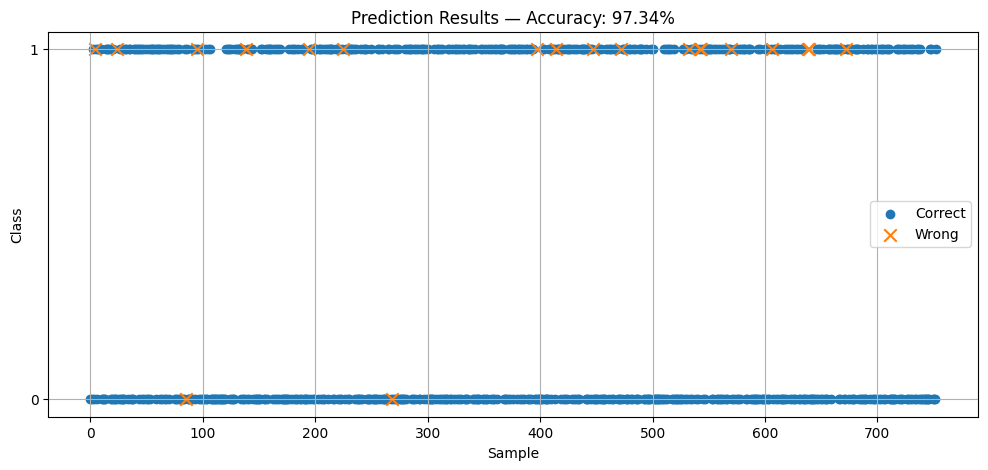

In [96]:
y_pred, accuracy = predict(w, b, X_val, y_val)

correct = y_pred == y_val
wrong = ~correct

plt.figure(figsize=(12, 5))

plt.scatter(
    np.arange(len(y_val))[correct],
    y_val[correct],
    marker='o',
    label='Correct'
)

plt.scatter(
    np.arange(len(y_val))[wrong],
    y_val[wrong],
    marker='x',
    s=80,
    label='Wrong'
)

plt.xlabel('Sample')
plt.ylabel('Class')
plt.title(f'Prediction Results — Accuracy: {accuracy * 100:.2f}%')

plt.yticks([0, 1])
plt.legend()
plt.grid(True)

plt.show()